# The bias--variance tradeoff, three ways

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/overfitting.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

The same tradeoff, told three times: as curve fitting, as a model-complexity curve, and as
the thing you actually do with one dataset.

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings
warnings.simplefilter("ignore")                  # high-degree polyfit is ill-conditioned; that is the point

rng = np.random.default_rng(166)
truth = lambda x: np.sin(2 * np.pi * x)          # what we are trying to recover
SD, N = 0.25, 20                                 # noise level, points per dataset

def dataset(n=N):
    x = np.sort(rng.uniform(0, 1, n))
    return x, truth(x) + rng.normal(0, SD, n)

## 1. Fitting a curve

Fit a polynomial to 20 noisy points. Do it 15 times, with fresh data each time, and draw
every fit. The truth is the black curve.

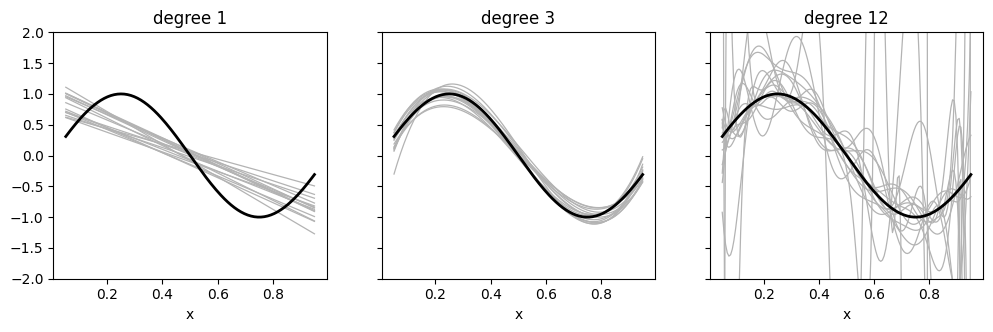

In [2]:
grid = np.linspace(0.05, 0.95, 150)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for a, deg in zip(ax, [1, 3, 12]):
    for _ in range(15):
        a.plot(grid, np.polyval(np.polyfit(*dataset(), deg), grid), color="0.7", lw=0.9)
    a.plot(grid, truth(grid), "k", lw=2)
    a.set_title(f"degree {deg}"); a.set_ylim(-2, 2); a.set_xlabel("x")
plt.show()

**Degree 1**: the fifteen lines lie almost on top of each other, and all of them are wrong.
The error is not in the data, it is in the model. That is **bias**.

**Degree 12**: every fit chases its own sample, and no two agree. Each one is close to its
own data and wildly far from the truth in between. That is **variance**.

**Degree 3** gets both about right. Note that neither failure is fixed by collecting a
cleaner sample: the flat model is wrong on any data, and the flexible one is unstable on any
data.

## 2. The complexity curve

The same experiment, made numerical. Over many datasets, at each $x$,

$$\underbrace{\big(\overline{\text{fit}}(x) - \text{truth}(x)\big)^2}_{\text{bias}^2}
\;+\; \underbrace{\text{Var}\big(\text{fit}(x)\big)}_{\text{variance}}$$

is the part of the error the model controls. (The noise $\sigma^2$ is a floor nothing can
remove.)

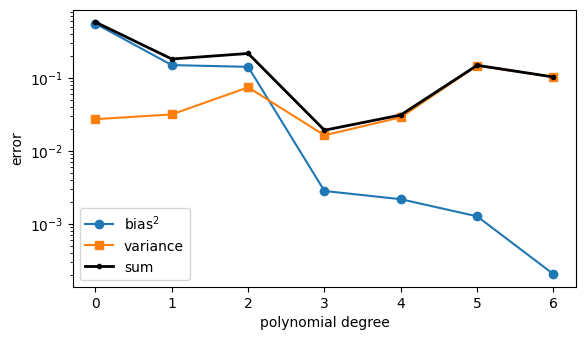

the sum is smallest at degree 3


In [3]:
degrees = range(7)
b2, var = [], []
for d in degrees:
    fits = np.array([np.polyval(np.polyfit(*dataset(), d), grid) for _ in range(400)])
    b2.append(np.mean((fits.mean(0) - truth(grid))**2))
    var.append(np.mean(fits.var(0)))
b2, var = np.array(b2), np.array(var)

plt.figure(figsize=(6.5, 3.6))
plt.semilogy(degrees, b2, "o-", label="bias$^2$")
plt.semilogy(degrees, var, "s-", label="variance")
plt.semilogy(degrees, b2 + var, "k.-", lw=2, label="sum")
plt.xlabel("polynomial degree"); plt.ylabel("error"); plt.legend(); plt.show()

print(f"the sum is smallest at degree {int(np.argmin(b2 + var))}")

Bias falls steeply as the model gets richer, variance climbs, and because they move in
opposite directions the sum has a minimum in between. Adding flexibility buys accuracy
until it stops paying for the instability it brings.

The bump at degree 2 is worth a look: $\sin(2\pi x)$ is odd about $x=\tfrac12$ and an even
polynomial cannot match that, so the quadratic term buys almost no bias and costs variance.
Extra parameters are not automatically useful --- they have to be the right ones.

This is the picture behind every model-selection knob in machine learning: the number of
layers, the depth of a tree, the number of neighbours, the size of a regularisation
penalty. They all trade the same two quantities.

## 3. What you can actually do

Sections 1 and 2 both cheated: they drew fresh datasets, and they compared against a truth
we knew. In practice you have **one** dataset and no truth, so neither bias nor variance can
be computed. What you can do is hold part of the data back.

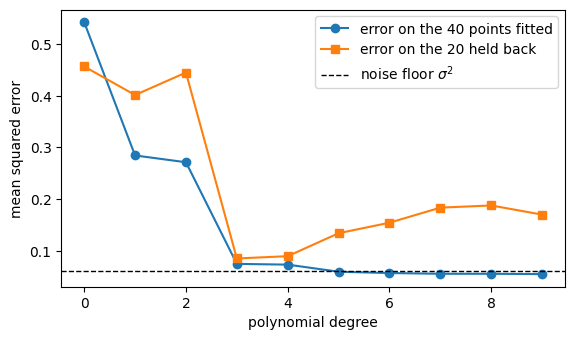

best on the fitted points: degree 9    best on the held-out points: degree 3


In [4]:
x, y = dataset(60)                               # the one dataset you have
i = rng.permutation(60); train, test = i[:40], i[40:]

tr = [np.mean((np.polyval(np.polyfit(x[train], y[train], d), x[train]) - y[train])**2) for d in range(10)]
te = [np.mean((np.polyval(np.polyfit(x[train], y[train], d), x[test]) - y[test])**2) for d in range(10)]

plt.figure(figsize=(6.5, 3.6))
plt.plot(range(10), tr, "o-", label="error on the 40 points fitted")
plt.plot(range(10), te, "s-", label="error on the 20 held back")
plt.axhline(SD**2, color="k", ls="--", lw=1, label="noise floor $\\sigma^2$")
plt.xlabel("polynomial degree"); plt.ylabel("mean squared error"); plt.legend(); plt.show()

print(f"best on the fitted points: degree {int(np.argmin(tr))}    best on the held-out points: degree {int(np.argmin(te))}")

The error on the points you fitted falls all the way down: a degree-9 polynomial always
describes the data it was given better than a straight line. Judged that way you would
always pick the most complicated model, which is exactly the wrong answer.

The held-out error turns back up, and its minimum is a usable estimate of the right
complexity. That is the whole practical content of the tradeoff: **fit quality is not
evidence, held-out error is.**

Two honest caveats. The held-out minimum is itself noisy --- re-run this cell with a
different split and it will move by a degree or two, which is why cross-validation averages
over several splits. And no model beats the noise floor $\sigma^2 = 0.0625$, drawn as the
dashed line: part of the error was never yours to remove.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. The decomposition it uses is Section 2.6 of
the lecture notes.